# Model Evaluation Metrics

## Objective

To evaluate a Logistic Regression model using F1 Score, ROC Curve, and AUC Score.

## Concepts Covered

- Precision
- Recall
- F1 Score
- ROC Curve
- AUC Score

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [4]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
data = df[
    ['pclass','sex','age','fare','survived']
].dropna()

data.head()

,pclass,sex,age,fare,survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0


In [6]:
data['sex'] = data['sex'].map({
    'male':0,
    'female':1
})

data.head()

,pclass,sex,age,fare,survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


In [7]:
X = data[
    ['pclass','sex','age','fare']
]

y = data['survived']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
predictions = model.predict(
    X_test
)

predictions[:10]

array([0, 1, 1, 1, 0, 0, 1, 1, 1, 1])

In [11]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[68 19]
 [16 40]]


In [12]:
accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions
)

recall = recall_score(
    y_test,
    predictions
)

print("Accuracy =", accuracy)
print("Precision =", precision)
print("Recall =", recall)

Accuracy = 0.7552447552447552
Precision = 0.6779661016949152
Recall = 0.7142857142857143


In [13]:
f1 = f1_score(
    y_test,
    predictions
)

print("F1 Score =", f1)

F1 Score = 0.6956521739130435


In [14]:
probabilities = model.predict_proba(
    X_test
)[:,1]

auc = roc_auc_score(
    y_test,
    probabilities
)

print("AUC =", auc)

AUC = 0.8109605911330049


In [15]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities
)

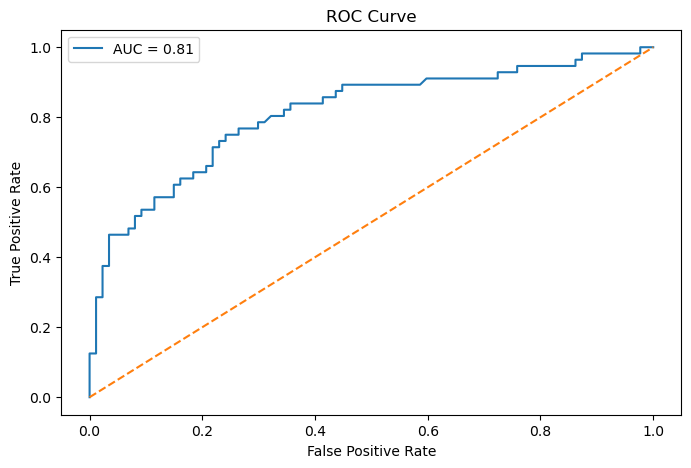

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

# Key Insights

1. F1 Score balances Precision and Recall.

2. ROC Curve shows model performance across thresholds.

3. AUC summarizes ROC performance into one number.

4. Higher AUC indicates better classification performance.

5. ROC-AUC is commonly used for evaluating classification models.